In [37]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data (1).zip


In [38]:
import zipfile
import os

zip_path = '/content/data.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import seaborn as sns

In [40]:
DATASET_PATH = '/content/dataset/data/natural_images'

In [41]:
classes = os.listdir(DATASET_PATH)

image_count = {}

total_images = 0

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(cls_path))
    image_count[cls] = count
    total_images += count

print("Total Images:", total_images)
print(image_count)

Total Images: 6899
{'dog': 702, 'fruit': 1000, 'person': 986, 'motorbike': 788, 'flower': 843, 'cat': 885, 'airplane': 727, 'car': 968}


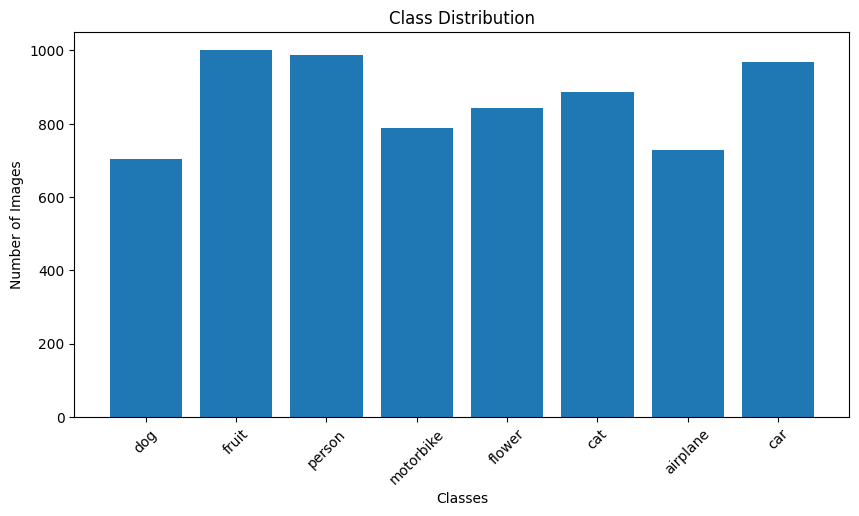

In [42]:
plt.figure(figsize=(10,5))
plt.bar(image_count.keys(), image_count.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

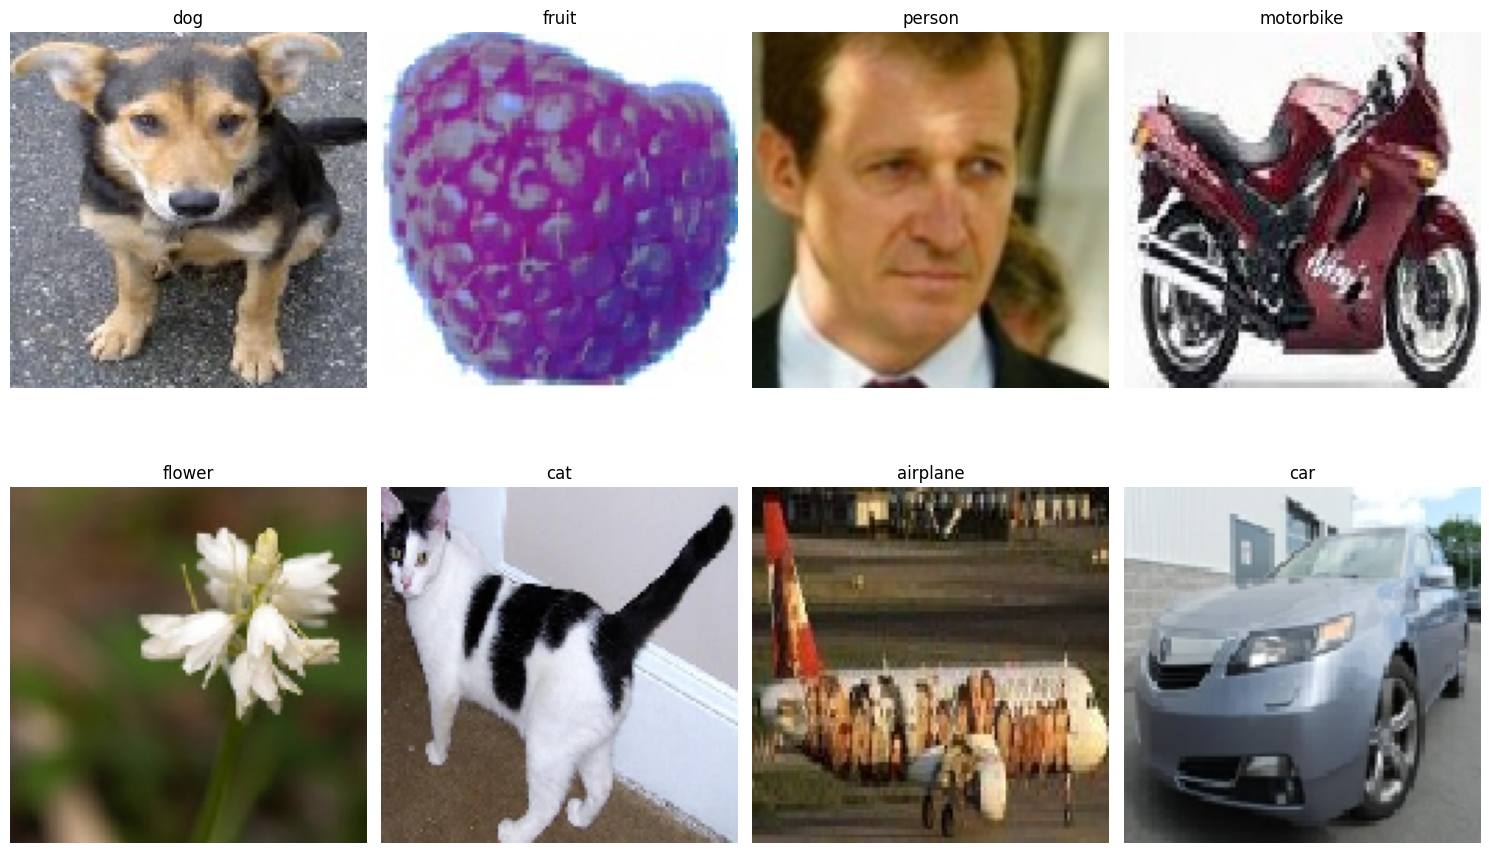

In [43]:
import random
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, cls)))
    img_path = os.path.join(DATASET_PATH, cls, img_name)

    img = image.load_img(img_path, target_size=(128,128))

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [44]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.


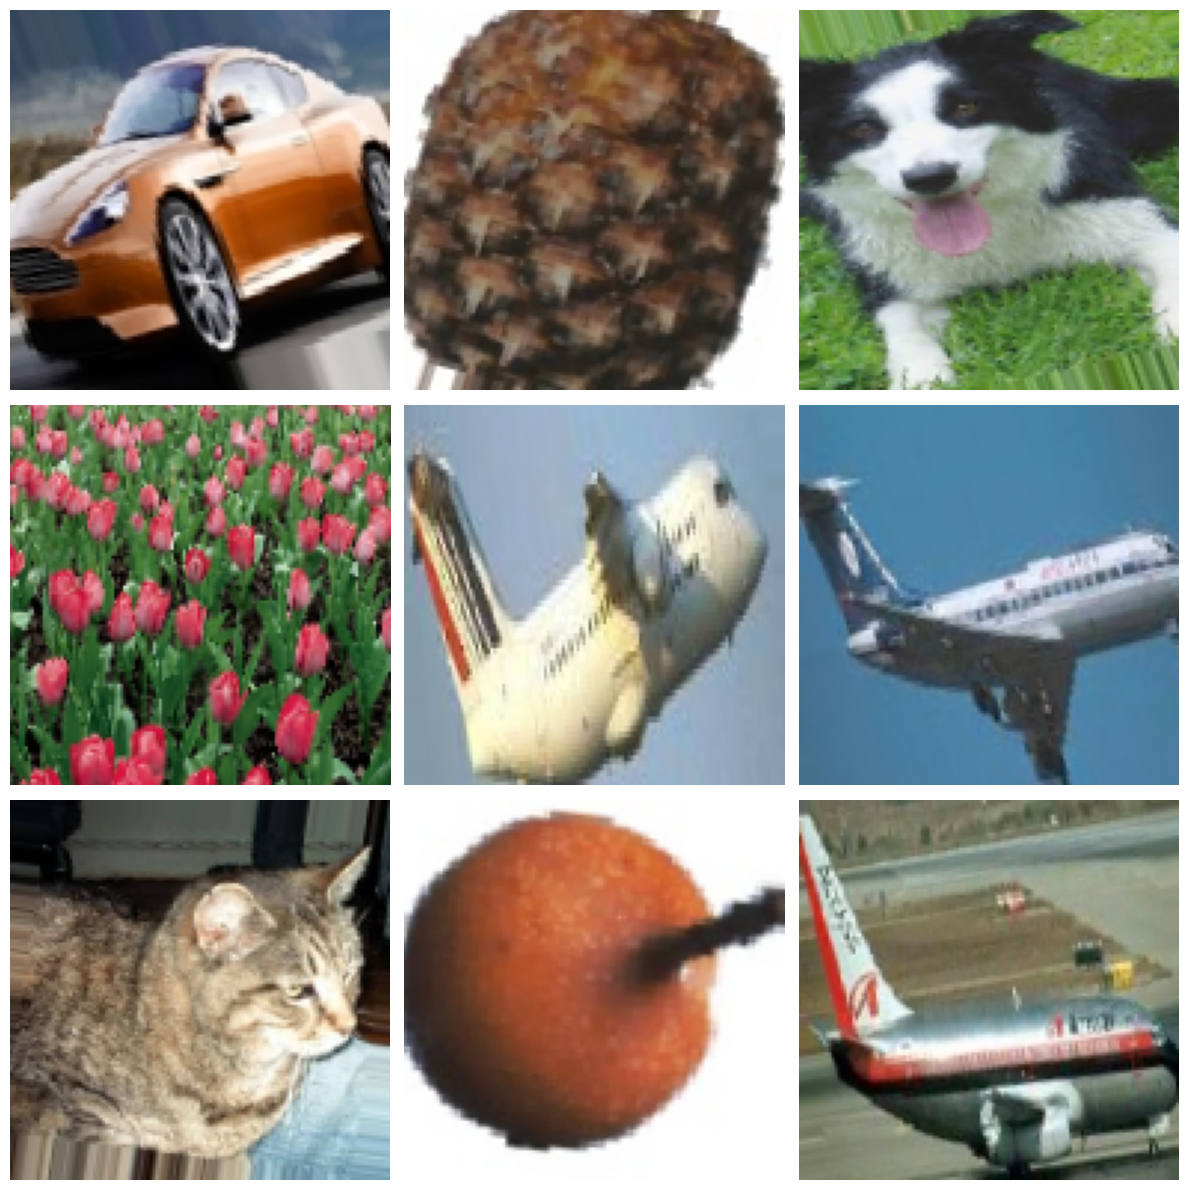

In [45]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(8, activation='softmax')
])

baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,704 (25.02 MB)

 Trainable params: 6,557,704 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.6947 - loss: 0.8404 - val_accuracy: 0.8025 - val_loss: 0.5644
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.8357 - loss: 0.4310 - val_accuracy: 0.8439 - val_loss: 0.4109
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 194ms/step - accuracy: 0.8756 - loss: 0.3313 - val_accuracy: 0.8831 - val_loss: 0.3081
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.8944 - loss: 0.2757 - val_accuracy: 0.8613 - val_loss: 0.4058
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.9018 - loss: 0.2565 - val_accuracy: 0.9005 - val_loss: 0.3047
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 199ms/step - accuracy: 0.9149 - loss: 0.2307 - val_accuracy: 0.8896 - val_loss: 0.3247
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - accuracy: 0.9263 - loss: 0.2104 - val_accuracy: 0.8700 - val_loss: 0.3533
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step - accuracy: 0.9305 - loss: 0

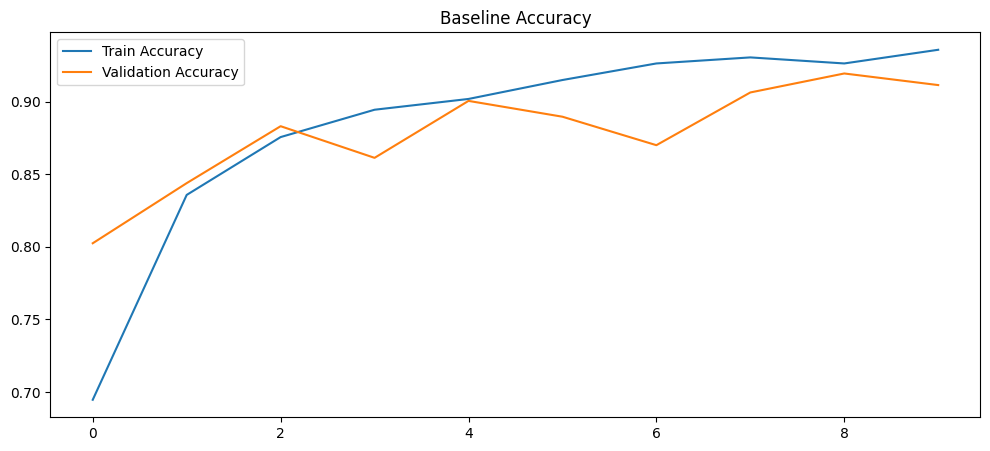

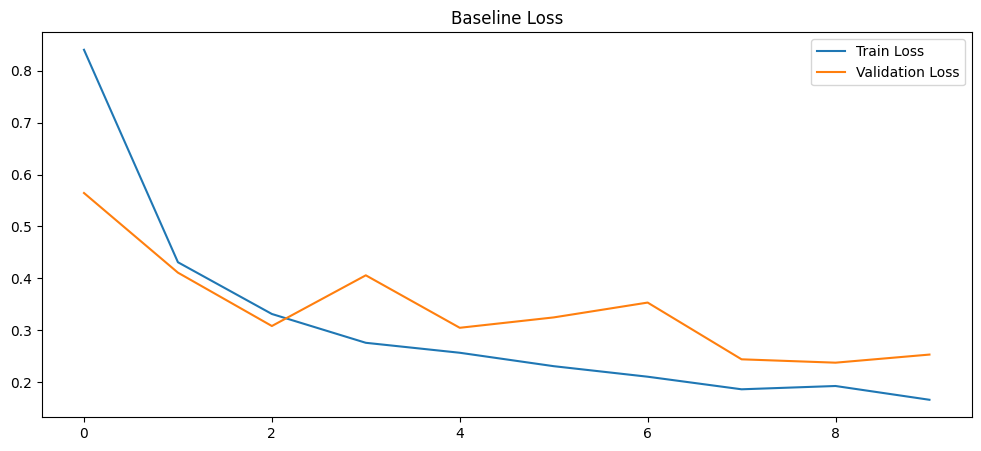

In [49]:
plt.figure(figsize=(12,5))

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Baseline Accuracy')
plt.show()
plt.figure(figsize=(12,5))

plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Baseline Loss')
plt.show()

In [50]:
baseline_loss, baseline_acc = baseline_model.evaluate(validation_generator)

print("Baseline Accuracy:", baseline_acc)

44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.9216 - loss: 0.2046
Baseline Accuracy: 0.9215686321258545


In [51]:
predictions = baseline_model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

print(classification_report(y_true, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step
              precision    recall  f1-score   support

           0       0.11      0.10      0.11       145
           1       0.13      0.13      0.13       193
           2       0.13      0.15      0.14       177
           3       0.08      0.07      0.08       140
           4       0.08      0.07      0.07       168
           5       0.17      0.17      0.17       200
           6       0.14      0.13      0.13       157
           7       0.12      0.12      0.12       197

    accuracy                           0.12      1377
   macro avg       0.12      0.12      0.12      1377
weighted avg       0.12      0.12      0.12      1377



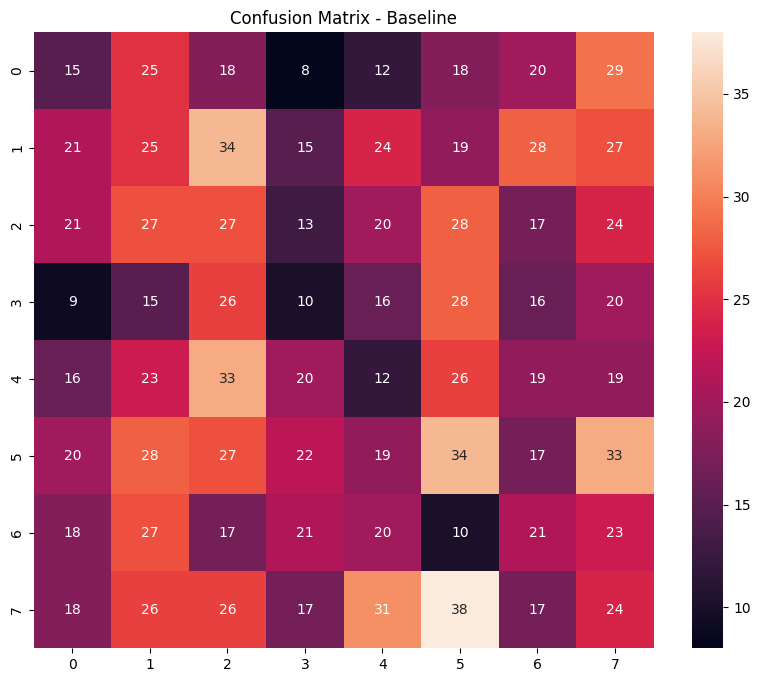

In [52]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Baseline')
plt.show()

In [53]:
deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(8, activation='softmax')
])


deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,786,888 (10.63 MB)

 Trainable params: 2,784,904 (10.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [54]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
history_deep = deep_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 51s 244ms/step - accuracy: 0.5654 - loss: 1.3880 - val_accuracy: 0.2527 - val_loss: 3.0945
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 194ms/step - accuracy: 0.7494 - loss: 0.7355 - val_accuracy: 0.4045 - val_loss: 1.9034
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accuracy: 0.7872 - loss: 0.6065 - val_accuracy: 0.7248 - val_loss: 0.7861
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 202ms/step - accuracy: 0.8316 - loss: 0.4714 - val_accuracy: 0.7553 - val_loss: 0.7401
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 204ms/step - accuracy: 0.8457 - loss: 0.4072 - val_accuracy: 0.7625 - val_loss: 0.7636
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 196ms/step - accuracy: 0.8635 - loss: 0.3881 - val_accuracy: 0.8395 - val_loss: 0.4935
Epoch 7/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 202ms/step - accuracy: 0.8778 - loss: 0.3422 - val_accuracy: 0.6558 - val_loss: 1.2349
Epoch 8/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 201ms/step - accuracy: 0.8732 - loss: 0

In [56]:
deep_loss, deep_acc = deep_model.evaluate(validation_generator)

print("Deeper Model Accuracy:", deep_acc)

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.8635 - loss: 0.4175
Deeper Model Accuracy: 0.8634713292121887


In [57]:
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - accuracy: 0.5281 - loss: 1.3862 - val_accuracy: 0.1438 - val_loss: 2.7144
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 197ms/step - accuracy: 0.7097 - loss: 0.8248 - val_accuracy: 0.2447 - val_loss: 3.4904
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - accuracy: 0.7662 - loss: 0.6450 - val_accuracy: 0.6710 - val_loss: 0.9046
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 202ms/step - accuracy: 0.8039 - loss: 0.5451 - val_accuracy: 0.6536 - val_loss: 1.1609
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 38s 219ms/step - accuracy: 0.8108 - loss: 0.5101 - val_accuracy: 0.4953 - val_loss: 2.2288
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 206ms/step - accuracy: 0.8435 - loss: 0.4224 - val_accuracy: 0.7262 - val_loss: 0.8560
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step - accuracy: 0.8562 - loss: 0.3989 - val_accuracy: 0.8402 - val_loss: 0.4734
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.8549 - loss: 0

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

In [ ]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

transfer_model.summary()

In [59]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
%%time
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 56s 268ms/step - accuracy: 0.9900 - loss: 0.0351 - val_accuracy: 0.9869 - val_loss: 0.0537
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.9893 - loss: 0.0376 - val_accuracy: 0.9877 - val_loss: 0.0471
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 196ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9833 - val_loss: 0.0487
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 198ms/step - accuracy: 0.9928 - loss: 0.0257 - val_accuracy: 0.9891 - val_loss: 0.0432
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.9933 - loss: 0.0251 - val_accuracy: 0.9847 - val_loss: 0.0642
Epoch 6/10
 88/173 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.9930 - loss: 0.0132

In [ ]:
transfer_loss, transfer_acc = transfer_model.evaluate(validation_generator)

print("Transfer Learning Accuracy:", transfer_acc)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/dataset/data/natural_images/car/car_0001.jpg'

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f'Predicted: {predicted_class}')
plt.axis('off')
plt.show()

In [36]:
transfer_model.save('vision_model.h5')